<a href="https://colab.research.google.com/github/mtnleo/Uni_AI_1/blob/main/Guia5_Leonardi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UNIVERSIDAD ATLANTIDA ARGENTINA
#INTELIGENCIA ARTIFICIAL 1

##PRACTICA 5

###TEMAS
* CLUSTERING
* CALIDAD DE AGRUPAMIENTO
* K-MODAS

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

# Cargar dataset
iris = load_iris()
nombre_archivo = '/content/drive/MyDrive/seeds_dataset.xlsx'

##Ejercicios Prácticos
Utilice los códigos del material de consulta (K_Modas.ipynb ,  Calidad_agrupamiento.ipynb) y los conceptos vistos en teoria para resolver los siguientes ejercicios.

## Calidad de Agrupamiento

**Ejercicio 1: Comparar diferentes métricas para elegir k**

1.  Genera un dataset con `make_blobs` usando 3 clusters.
2.  Calcula SSE (metodo del codo) y silueta para k de 2 a 6.
3.  ¿Ambos métodos sugieren el mismo k óptimo? ¿Por qué?

---

**Ejercicio 2: Pureza con diferentes algoritmos**

1.  Usando el dataset Iris, aplica K-Means con k=3.
2.  Calcula la pureza comparando con las etiquetas reales de las flores.
3.  ¿Qué tan bien se alinean los clusters con las especies reales?

---

**Ejercicio 3: Visualización avanzada de silueta**

1.  Explicar el algoritmo de calculo del coeficiente promedio de silueta.
2.  Comparelo com el metodo de Codo.

---




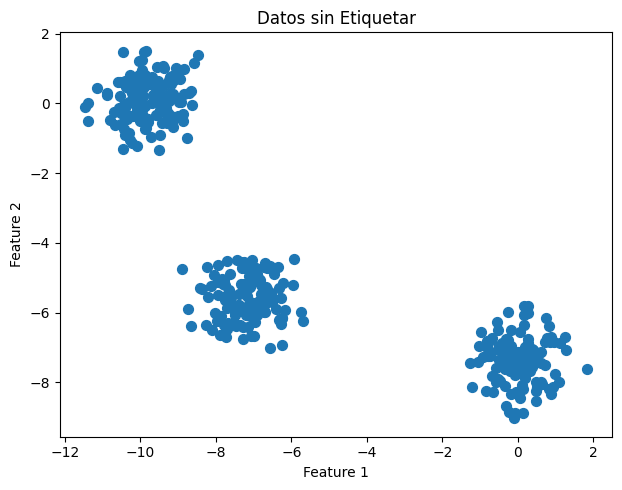

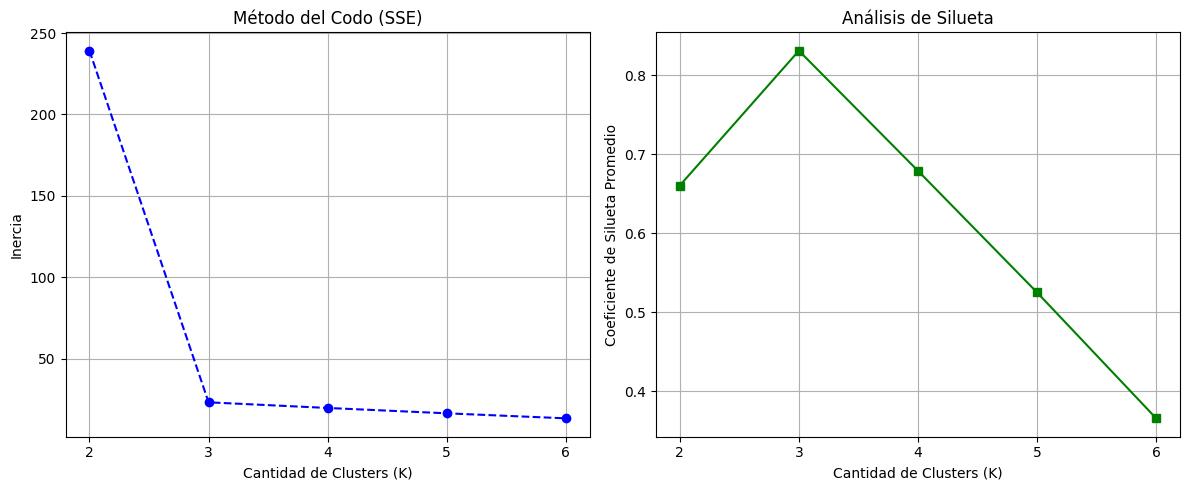

'\nSí, ambos sugieren K=3.\n  En el gráfico del Codo (SSE), K=3 es el punto de inflexión donde la ganancia \nde agregar más clusters disminuye drásticamente.\n  En el gráfico de la Silueta, K=3 es el punto donde la métrica alcanza su valor\nmáximo (más cercano a 1), lo que indica que para ese K, los puntos están\nmuy cohesionados en sus propios clusters y muy bien separados de\nlos clusters vecinos.\n'

In [5]:
##### Ejercicio 1: Comparar diferentes métricas para elegir k
# 1. Genera un dataset con make_blobs usando 3 clusters.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X_blobs, y_blobs = make_blobs(n_samples=400, centers=3, cluster_std=0.60, random_state=9)

df_blobs = pd.DataFrame(X_blobs, columns=['Feature1', 'Feature2'])
df_blobs['Cluster_Real'] = y_blobs

###
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50)
plt.title('Datos sin Etiquetar')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()
###

X_features = df_blobs.drop(columns=['Cluster_Real'])
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_features)

# 2. Calcula SSE (inercia) y silueta para k de 2 a 6.


inercias = []
siluetas = []
valores_k = range(2, 7) # Rango de 2 a 6 inclusive

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_pred = kmeans.fit_predict(X_std)

    # Guardamos ambas métricas
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_std, etiquetas_pred))

# Graficamos los resultados comparativos
plt.figure(figsize=(12, 5))

# Gráfico del Método del Codo (SSE)
plt.subplot(1, 2, 1)
plt.plot(valores_k, inercias, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (SSE)')
plt.xlabel('Cantidad de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(valores_k)
plt.grid(True)

# Gráfico de la Silueta Promedio
plt.subplot(1, 2, 2)
plt.plot(valores_k, siluetas, marker='s', linestyle='-', color='g')
plt.title('Análisis de Silueta')
plt.xlabel('Cantidad de Clusters (K)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.xticks(valores_k)
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. ¿Ambos métodos sugieren el mismo k óptimo? ¿Por qué?
"""
Sí, ambos sugieren K=3.
  En el gráfico del Codo (SSE), K=3 es el punto de inflexión donde la ganancia
de agregar más clusters disminuye drásticamente.
  En el gráfico de la Silueta, K=3 es el punto donde la métrica alcanza su valor
máximo (más cercano a 1), lo que indica que para ese K, los puntos están
muy cohesionados en sus propios clusters y muy bien separados de
los clusters vecinos.
"""

##K-Modas
**Ejercicio 1: Experimentar con el número de clusters**
1.  Modificar el número de clusters (K=2, K=4) y analizar cómo cambian los perfiles.
2. Probar los diferentes métodos de inicialización:
   - init='random'
   - init='Huang'
   - init='Cao'
   ¿Cuál da mejor resultado (menor costo)?
3. Agregar un nuevo atributo: 'Frecuencia_visita' = ['semanal', 'quincenal', 'mensual']
   ¿Cómo cambian los clusters?
4. Predecir el cluster para un nuevo cliente con K-Prototypes:
   Cabello='castaño', Ojos='verde', Piel='clara', Edad=33, Tratamiento_favorito='hidratación'

5. Implementar una métrica de evaluación adicional: silhouette_score adaptada para kmodes.   

In [7]:
pip install kmodes

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes
import warnings
warnings.filterwarnings('ignore')


# Datos de clientes
clientes = pd.DataFrame({
    'Cliente_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Cabello': ['rubio', 'castaño', 'rojo', 'negro', 'castaño', 'negro',
                'rojo', 'negro', 'rubio', 'castaño', 'rubio', 'negro'],
    'Ojos': ['ámbar', 'gris', 'verde', 'almendra', 'ámbar', 'gris',
             'verde', 'almendra', 'ámbar', 'verde', 'ámbar', 'gris'],
    'Piel': ['clara', 'morena', 'morena', 'morena', 'clara', 'morena',
             'clara', 'clara', 'clara', 'morena', 'clara', 'morena'],
    'Tratamiento_favorito': ['hidratación', 'limpieza', 'peeling', 'masajes',
                              'hidratación', 'peeling', 'masajes', 'limpieza',
                              'hidratación', 'limpieza', 'peeling', 'masajes']
})

print("="*60)
print("DATOS DE CLIENTES")
print("="*60)
print(clientes.to_string(index=False))


  # Preparar datos para K-Modas
X = clientes[['Cabello', 'Ojos', 'Piel', 'Tratamiento_favorito']].values

# 1. Modificar el número de clusters (K=2, K=4) y analizar cómo cambian los perfiles.
# 2. Probar los diferentes métodos de inicialización:
# init='random'
# init='Huang'
# init='Cao' ¿Cuál da mejor resultado (menor costo)?
k_range = [2, 4]
inicializaciones = ['random', 'Huang', 'Cao']
max_iter = 300
costos = []

for k in k_range:
  for init_mode in inicializaciones:
    km = KModes(n_clusters=k, init=init_mode, n_init=5,max_iter=max_iter, random_state=42, verbose=0)
    km.fit_predict(X)
    costos.append(km.cost_)
    print(f"K = {k}: Costo = {km.cost_:.2f} - Modelo: {init_mode}")

# Como se puede observar, hubo un empate en los costos y modelos
# en 2 clusters. Sin embargo en 4 clusters, Cao resultó ser el peor,
# y más caro. Mientras que random y Huang dieron un mejor resultado

# 3. Agregar un nuevo atributo: 'Frecuencia_visita' = ['semanal', 'quincenal', 'mensual'] ¿Cómo cambian los clusters?

clientes['Frecuencia_visita'] = ['semanal', 'quincenal', 'mensual'] * 4
X = clientes[['Cabello', 'Ojos', 'Piel', 'Tratamiento_favorito', 'Frecuencia_visita']].values
print("="*60)
print("DATOS DE CLIENTES")
print("="*60)
print(clientes.to_string(index=False))

for k in k_range:
  for init_mode in inicializaciones:
    km = KModes(n_clusters=k, init=init_mode, n_init=5,max_iter=max_iter, random_state=42, verbose=0)
    km.fit_predict(X)
    costos.append(km.cost_)
    print(f"K = {k}: Costo = {km.cost_:.2f} - Modelo: {init_mode}")

# Aumenta el costo pero sigue teniendo el mismo resultado

# 4. Predecir el cluster para un nuevo cliente con K-Prototypes: Cabello='castaño', Ojos='verde', Piel='clara', Edad=33, Tratamiento_favorito='hidratación'

# 5. Implementar una métrica de evaluación adicional: silhouette_score adaptada para kmodes.

DATOS DE CLIENTES
 Cliente_ID Cabello     Ojos   Piel Tratamiento_favorito
          1   rubio    ámbar  clara          hidratación
          2 castaño     gris morena             limpieza
          3    rojo    verde morena              peeling
          4   negro almendra morena              masajes
          5 castaño    ámbar  clara          hidratación
          6   negro     gris morena              peeling
          7    rojo    verde  clara              masajes
          8   negro almendra  clara             limpieza
          9   rubio    ámbar  clara          hidratación
         10 castaño    verde morena             limpieza
         11   rubio    ámbar  clara              peeling
         12   negro     gris morena              masajes
K = 2: Costo = 17.00 - Modelo: random
K = 2: Costo = 17.00 - Modelo: Huang
K = 2: Costo = 17.00 - Modelo: Cao
K = 4: Costo = 10.00 - Modelo: random
K = 4: Costo = 10.00 - Modelo: Huang
K = 4: Costo = 11.00 - Modelo: Cao
DATOS DE CLIENTES
 Cl